In [2]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")

import numpy as np
import time
import copy
from PIL import Image
import cv2
import open3d as o3d
import importlib
import imutils
import matplotlib.pyplot as plt
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object, label_wrist_image_rotation_axes
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
from magpie_control import poses
import spatialmath as sm
reload_modules(pcd, utils, real, ur5, gripper)

# rerun viz
import rerun as rr
from rerun_rlds_ur5.rlds import RLDSDataset, DeliGraspTrajectory, LiveRobotData
from rerun_rlds_ur5.rerun_loader_urdf import URDFLogger, get_urdf_paths, update_urdf
reload_modules(LiveRobotData, URDFLogger)
ur5_urdf, _, _= get_urdf_paths("ur5")
rr.init("ScalingForce-visualized", spawn=True)
urdf_logger = URDFLogger(ur5_urdf)
urdf_logger.log()
rr.log("annotation", rr.TextDocument("annotation_1",media_type="text/markdown"))
rerun_viz = LiveRobotData(entity_to_transform=urdf_logger.entity_to_transform)
rr.send_blueprint(rerun_viz.blueprint())

# with help from: https://github.com/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb
import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
reload_modules(sf_force_thinker, sf_grasp_selection, conversation, sf_force_reflection)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4o"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.
Module LiveRobotData is not currently imported.
Module URDFLogger is not currently imported.


[2025-04-11T19:51:06Z INFO  re_sdk::spawn] A process is already listening at this address. Assuming it's a Rerun Viewer. addr=0.0.0.0:9876


In [3]:
from magpie_perception.label import Label
from magpie_perception.label_owlvit import LabelOWLViT
from magpie_perception.label_owlv2  import LabelOWLv2
from magpie_perception.label_dino   import LabelDINO
from magpie_perception.mask_sam2    import MaskSAM2

label_models = {'owl-vit': LabelOWLViT(),
                'owl-v2':  LabelOWLv2(),
                'dino':    LabelDINO(),}
mask_models = {'mask': MaskSAM2(),
               'box-dbscan': None}
label_model = label_models['owl-vit']
label_model = label_models['owl-v2']
label_model.init()

/home/will/miniconda3/envs/octo/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [4]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=6, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


# Grasp Localization and Initial Motion

In [5]:
user_query = "push the blue water cup forward on the table, don't know how much water is in it"
SAVE = False
STEP = 0
log_time = time.time()
LOG_NAME = f"scalingforce/{user_query}_log_{log_time}"
if not os.path.exists(LOG_NAME):
    os.makedirs(LOG_NAME)
MESSAGES = []
RESPONSES = []


middle of blue cup
[(array([ 62.429, 159.997, 599.587, 333.085], dtype=float32), 0), (array([292.151, 417.737, 303.917, 443.161], dtype=float32), 0), (array([249.965, 399.371, 288.362, 480.59 ], dtype=float32), 0), (array([ 63.782, 161.248, 543.251, 334.12 ], dtype=float32), 0), (array([412.109, 340.917, 427.443, 357.68 ], dtype=float32), 0), (array([381.692, 326.401, 412.169, 366.848], dtype=float32), 0), (array([548.111, 240.659, 607.581, 261.439], dtype=float32), 0), (array([ 55.154, 157.821, 627.275, 332.072], dtype=float32), 0), (array([276.502, 356.18 , 292.334, 394.319], dtype=float32), 0), (array([2.011e-01, 1.321e+00, 2.953e+02, 4.752e+02], dtype=float32), 0), (array([420.991, 352.054, 441.66 , 363.772], dtype=float32), 0), (array([422.688, 358.368, 457.029, 369.54 ], dtype=float32), 0), (array([297.149, 372.39 , 311.795, 428.98 ], dtype=float32), 0), (array([294.053, 418.716, 302.723, 439.419], dtype=float32), 0), (array([318.541, 325.353, 370.841, 409.308], dtype=float32), 0

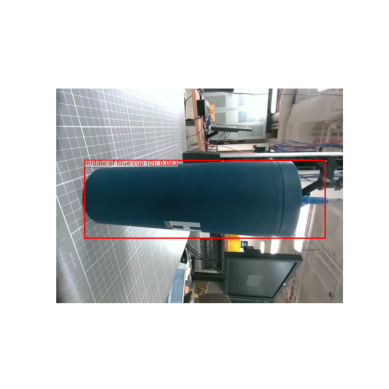

In [6]:
pcd_wrist, rgbd_wrist = wrist.getPCD()
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

img_wrist = np.array(rgbd_wrist.color).copy()
img_wkspc = np.array(rgbd_wkspc.color)

grasp_prompt = sf_grasp_selection.grasp_prompt.format(**{"user_query": user_query})
img = Image.fromarray(img_wrist)
image_response = gemini_client.models.generate_content(
    model=GEMINI_MODEL_ID,
    contents=[grasp_prompt, img],
)
# image_response = send_message(gemini_client, model=GEMINI_MODEL_ID, messages=[grasp_prompt, img], model_type="gemini")
grasp_phrase = image_response.text.split("\n")[-1].split(": ")[-1]
print(grasp_phrase)

query = [grasp_phrase]
seg_type = 'box-dbscan'
mask_model = mask_models[seg_type]
pcd_wrist, rgbd_wrist = wrist.getPCD()
pose, pred_image = find_object(rgbd_wrist, query, label_model, mask_model, seg_type, wrist)
np.save(f"{LOG_NAME}/init_moveto_pose.npy", pose)
print(pose)
print(plt.get_backend())
%matplotlib inline
plt.imshow(pred_image)
plt.axis('off')  # Optional: to hide axis values and ticks
plt.show()

In [8]:
ROBOT_IP = "192.168.0.4"
robot = ur5.UR5_Interface(ROBOT_IP, 
                            freq=6, # 6Hz frequency
                            record=False,
                            provide_gripper=True,
                            provide_ft_sensor=True,)
robot.start()
robot.start_ft_sensor()
robot.moveL_translation_tooltip(pose, z_offset=0.02, asynch=False)


Found Dynamixel Port:
/dev/ttyACM0

Succeeded to open the port
Succeeded to change the baudrate
Tooltip: [0.012 0.006 0.211]
Goal Pos: [-0.101 -0.228  0.206]


# Physical Reasoning for Forceful Motion Plan

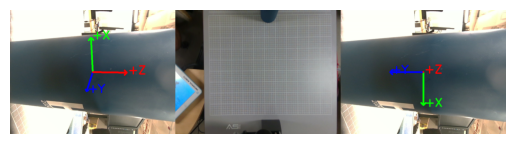

In [9]:
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()
pcd_wrist, rgbd_wrist = wrist.getPCD()
img_wrist = np.array(rgbd_wrist.color)
img_wkspc = np.array(rgbd_wkspc.color)

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(robot.getPose())
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_labeled = label_wrist_image_rotation_axes(img_wrist.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_labeled_base = label_wrist_image_rotation_axes(img_wrist.copy(), R_cr, intrinsics, axis_length=0.03)
final_img = np.hstack((img_wrist_labeled_base, img_wkspc, img_wrist_labeled))
# final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
fn = f"{LOG_NAME}/init_axes_{user_query}.png"
cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)

In [10]:
model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    client_structured = instructor.from_openai(client=client)
    model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    client_structured = instructor.from_genai(client=client)
    model = GEMINI_MODEL_ID
img = Image.open('scalingforce/axes7_double_wrist.png').convert("RGB")

# obj = "small servo motor"
prompt_config = {
"obj": grasp_phrase,
"task": user_query
}
# obj = "small servo motor"
# prompt_config = {
# "obj": "small servo motor",
# "task": f"slide the {obj} rapidly up the table for 10 cm"
# }

prompt = sf_force_thinker.prompt_motion_thinker.format(**prompt_config)
MESSAGES = build_messages(prompt, img, messages=MESSAGES, model_type=model_type)
response = send_message(client, model, MESSAGES, model_type=model_type)
motion_plan = force_thinker.process_thinker_response(response)
np.save(f"{LOG_NAME}/response-{STEP}.npy", response, allow_pickle=True)
np.save(f"{LOG_NAME}/motion_plan-{STEP}.npy", motion_plan, allow_pickle=True)
print(response)
MESSAGES = build_messages(response, image=None, messages=MESSAGES, model_type=model_type, role="assistant")
RESPONSES = build_messages(response, image=None, messages=RESPONSES, model_type=model_type)
motion_plan

[start of motion plan]
The task is to push the blue water cup forward on the table, don't know how much water is in it while grasping the middle of blue cup.

Aligning Images With Wrist Motion:
The provided images in the three-part image confirm that the object is a blue plastic cup with unknown amount of water inside and is resting on a table with a grid pattern.
The green axis representing the positive X-axis along the wrist corresponds to pushing the blue cup towards the object, roughly aligned to the positive world X axis.
The blue axis representing negative Y-axis along the wrist corresponds to pushing the blue cup to the left of the object, roughly aligned to the positive world Y axis.
The red dot representing the positive Z-axis (into the page) along the wrist corresponds to pressing down on the cup, aligned to the negative world Z axis.
Thus, in order to complete the task, the required linear wrist motion along the green axis representing the positive X-axis is positive to push

{'position_direction': [1, 0, -1],
 'position_goal': [0.1, 0.0, 0.01],
 'wrench': [2.0, 0.0, -1.5, 0.0, 0.0, 0.0],
 'grasp_force': 3.5,
 'duration': 2.0}

# Robot Motion Execution

In [11]:
importlib.reload(ur5)
importlib.reload(gripper)
# ROBOT_IP = "192.168.0.4"
# robot = ur5.UR5_Interface(ROBOT_IP, 
#                             freq=6, # 6Hz frequency
#                             record=False,
#                             provide_gripper=True,
#                             provide_ft_sensor=True,)
# robot.start()
robot.start_ft_sensor(poll_rate=100)
G = robot.gripper
G.reset_parameters()
np.save(f"{LOG_NAME}/init_home.npy", robot.home)
pose = np.load(f"{LOG_NAME}/init_moveto_pose.npy")

In [26]:
import numpy as np
motion_plan = np.load(f"{LOG_NAME}/motion_plan-{STEP}.npy", allow_pickle=True).item()
G.reset_and_close_gripper(force_limit=10)
print(motion_plan)

camera_dict = {
    wrist: "record/wrist/",
    wkspc: "record/workspace/"
}
goal_delta = np.array(motion_plan['position_goal'])
direction = np.array(motion_plan['position_direction'])
sign = np.where(np.hstack((direction, np.zeros(3))) < 0, -1, 1)
# force = np.array(motion_plan['force']) * sign * -1
wrench = np.array(motion_plan['wrench']) * sign 
wrench_goal = wrench * -1
init_cmd = np.hstack((wrench[:3] / 300, wrench[3:] / 15))
# wrench_goal = np.hstack((force, np.zeros(3)))
# init_cmd = np.hstack((force / -300, np.zeros(3)))
duration = motion_plan['duration']
# duration = 8
grasp_force = motion_plan['grasp_force']
# grasp_force = 10
P = 0.0003 # stiffness gain, default is 0.0005

# TODO: add a re-zero ft sensor function, but for now just restart it
robot.start_ft_sensor()

print(init_cmd)
print(wrench_goal)

motion_log = await robot.concurrent_gripper_camera_robot_control(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, 
                                        #  camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.01, rerun_viz=rerun_viz,
                                         camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.01, rerun_viz=None,
                                         duration=duration, p=P, control_type="bang_bang")
robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)
STEP += 1

[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
{'position_direction': [1, 0, -1], 'position_goal': [0.1, 0.0, 0.01], 'wrench': [2.0, 0.0, -1.5, 0.0, 0.0, 0.0], 'grasp_force': 3.5, 'duration': 2.0}
[0.007 0.    0.005 0.    0.    0.   ]
[-2.  -0.  -1.5 -0.  -0.  -0. ]
D405 Recording Started
D435 Recording Started
D405 Recording Task Cancelled
D405 Recording Stopped
D435 Recording Task Cancelled
D435 Recording Stopped


In [16]:
import time
import os
if SAVE:
    episode_time = time.time()
    episode_name = f"{LOG_NAME}/episode_{STEP}_{episode_time}"
    text_messages = [i for i in MESSAGES if type(i) == str]
    # create directory if it doesn't exist
    if not os.path.exists(episode_name):
        os.makedirs(episode_name)
    np.save(f"{episode_name}/query_image.npy", final_img, allow_pickle=True)
    np.save(f"{episode_name}/messages.npy", text_messages, allow_pickle=True)
    np.save(f"{episode_name}/gripper_log.npy", motion_log['gripper'],allow_pickle=True)
    np.save(f"{episode_name}/robot_log.npy", motion_log['robot'],allow_pickle=True)
    np.save(f"{episode_name}/wrist_log.npy", motion_log['record/wrist/'],allow_pickle=True)
    np.save(f"{episode_name}/wkspc_log.npy", motion_log['record/workspace/'],allow_pickle=True)

In [27]:
for key in motion_log:
    ts = motion_log[key].keys()
    last_ts = sorted(ts)[-1]
    first_ts = sorted(ts)[0]
    print(f"sensor {key} first timestamp: {first_ts}")
    print(f"sensor {key} last timestamp: {last_ts}")
    duration = last_ts - first_ts
    length = len(motion_log[key])
    print(f"sensor {key} duration: {duration}, length: {length}, Hz: {length/duration}\n")

sensor gripper first timestamp: 1744402397.5981433
sensor gripper last timestamp: 1744402399.4694233
sensor gripper duration: 1.8712799549102783, length: 12, Hz: 6.412722996637539

sensor robot first timestamp: 1744402397.5345356
sensor robot last timestamp: 1744402399.5198066
sensor robot duration: 1.9852709770202637, length: 97, Hz: 48.859828770372395

sensor record/wrist/ first timestamp: 1744402397.4537008
sensor record/wrist/ last timestamp: 1744402399.5205283
sensor record/wrist/ duration: 2.0668275356292725, length: 15, Hz: 7.257499593662543

sensor record/workspace/ first timestamp: 1744402397.199012
sensor record/workspace/ last timestamp: 1744402399.3704722
sensor record/workspace/ duration: 2.1714601516723633, length: 14, Hz: 6.447274654898831



# Feedback

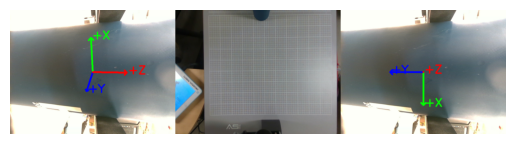

In [28]:
gripper_log = motion_log['gripper']
robot_log   = motion_log['robot']
wrist_log   = motion_log['record/wrist/']
wkspc_log   = motion_log['record/workspace/']
gripper_ts   = sorted(gripper_log.keys())
robot_ts     = sorted(robot_log.keys())
wrist_ts     = sorted(wrist_log.keys())
wkspc_ts     = sorted(wkspc_log.keys())

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[robot_ts[-1]]['actual_TCP_pose']))))
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_final = wrist_log[wrist_ts[-1]]['rgb']
img_wkspc_final = wkspc_log[wkspc_ts[-1]]['rgb']
img_wrist_final_labeled = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_final_labeled_base = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cr, intrinsics, axis_length=0.03)
feedback_img = np.hstack((img_wrist_final_labeled_base, img_wkspc_final, img_wrist_final_labeled))
# final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
fn = f"{LOG_NAME}/axes_step-{STEP}_{user_query}.png"
cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(feedback_img)

In [31]:
from spatialmath.base import rodrigues, tr2rpy
import numpy as np

motion_report = ""
motion_report += f"Initial Motion Plan: {motion_plan}\n"
# get first and last TCP pose of robot log
first_pose = np.array(robot_log[robot_ts[0]]['actual_TCP_pose'])
last_pose =  np.array(robot_log[robot_ts[-1]]['actual_TCP_pose'])
dist =  last_pose - first_pose
# get the rotation matrix from the wrist frame to the robot frame
rot = rodrigues(first_pose[3:6])
# transform distance to be relative to the first TCP wrist frame, use inverse of rot
dist_wrist = rot.T @ dist[:3]
motion_report += f"Motion Plan Results: \nDistance traveled relative to original wrist base frame [x, y, z] (m) axes: {dist_wrist.round(3)}\n"
motion_report += f"Distance traveled along base frame [x, y, z] (m) axes: {dist[:3].round(3)}\n"

# Use a simple moving average with a window size of downsample_factor
def moving_average(data, window_size):
    return np.array([np.mean(data[i:i+window_size], axis=0) for i in range(0, len(data), window_size)])

def get_report(desired_freq, timestamps, log, name, description):
    log_dur = timestamps[-1] - timestamps[0]
    log_flat = np.array([log[i][name] for i in timestamps])
    num_downsampled_entries = int(log_dur // (1 / desired_freq))
    downsample_factor = len(timestamps) // num_downsampled_entries
    downsampled_log = moving_average(log_flat, downsample_factor)
    summary = f"\n{description} Log Summary:"
    summary += f"\nMotion Duration: {log_dur}s"
    summary += f"\nAverage {name} Downsampled at {desired_freq}Hz:"
    for i, entry in enumerate(downsampled_log):
        summary += f"\n{i*(1/desired_freq)}s to {(i+1)*(1/desired_freq)}: {entry.round(2)}"
    summary += f"\nOverall Average Across Episode: {np.mean(downsampled_log, axis=0).round(2)}"
    return summary
desired_freq = 2
wrench_report = get_report(desired_freq, robot_ts, robot_log, "wrench", "6D Wrench [x, y, z, rx, ry, rz] (N and Nm)")
# print(wrench_report)
motion_report += f"{wrench_report}\n"

gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_l", "Left Gripper Contact Force (N)")
motion_report += f"{gripper_report}\n"
gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_r", "Right Gripper Contact Force (N)")
# print(gripper_report)
motion_report += f"{gripper_report}\n"

print(motion_report)

Initial Motion Plan: {'position_direction': [1, 0, -1], 'position_goal': [0.1, 0.0, 0.01], 'wrench': [2.0, 0.0, -1.5, 0.0, 0.0, 0.0], 'grasp_force': 3.5, 'duration': 2.0}
Motion Plan Results: 
Distance traveled relative to original wrist base frame [x, y, z] (m) axes: [ 0.011 -0.     0.007]
Distance traveled along base frame [x, y, z] (m) axes: [-0.013 -0.002 -0.001]

6D Wrench [x, y, z, rx, ry, rz] (N and Nm) Log Summary:
Motion Duration: 1.9852709770202637s
Average wrench Downsampled at 2Hz:
0.0s to 0.5: [-0.28 -0.23  0.34  0.04 -0.03  0.02]
0.5s to 1.0: [-0.47 -0.84 -0.15  0.11 -0.07  0.04]
1.0s to 1.5: [-0.55 -1.21  0.08  0.14 -0.07  0.04]
1.5s to 2.0: [-0.4  -0.5   1.2   0.1  -0.08  0.05]
Overall Average Across Episode: [-0.42 -0.7   0.37  0.1  -0.06  0.04]

Left Gripper Contact Force (N) Log Summary:
Motion Duration: 1.8712799549102783s
Average cf_l Downsampled at 2Hz:
0.0s to 0.5: 1.73
0.5s to 1.0: 1.73
1.0s to 1.5: 1.73
Overall Average Across Episode: 1.73

Right Gripper Contac

In [32]:
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection
from magpie_prompts import conversation
reload_modules(conversation, sf_force_thinker, sf_grasp_selection, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message

# feedback_messages = messages.copy()
feedback_messages = RESPONSES.copy() # pass by reference now to keep history
feedback_prompt_config = prompt_config.copy()
feedback_prompt_config['results'] = motion_report
feedback_prompt = sf_force_reflection.prompt_motion_reflection.format(**feedback_prompt_config)
img_final_PIL = Image.fromarray(final_img).convert("RGB")
MESSAGES = build_messages(feedback_prompt, img_final_PIL, messages=MESSAGES, model_type=model_type)
feedback_messages = build_messages(feedback_prompt, img_final_PIL, messages=feedback_messages, model_type=model_type)
feedback_response = send_message(client, model, feedback_messages, model_type=model_type)
MESSAGES = build_messages(feedback_response, image=None, messages=MESSAGES, model_type=model_type, role="assistant")
RESPONSES = build_messages(feedback_response, image=None, messages=RESPONSES, model_type=model_type)

print(feedback_response)
force_reflector = sf_force_reflection.PromptForceReflection()
motion_feedback_plan = force_reflector.process_thinker_response(feedback_response)
np.save(f"{LOG_NAME}/response-{STEP}.npy", response, allow_pickle=True)
np.save(f"{LOG_NAME}/motion_plan-{STEP}.npy", motion_plan, allow_pickle=True)
print(motion_feedback_plan)

[start of motion plan]
The task is to push the blue water cup forward on the table, don't know how much water is in it while grasping the middle of blue cup.

Aligning Images With Wrist Motion:
The provided images in the three-part image confirm that the object is a blue plastic cup with unknown amount of water inside and is resting on a table with a grid pattern.
The green axis representing the positive X-axis along the wrist corresponds to pushing the blue cup towards the object, roughly aligned to the positive world X axis.
The blue axis representing negative Y-axis along the wrist corresponds to pushing the blue cup to the left of the object, roughly aligned to the positive world Y axis.
The red dot representing the positive Z-axis (into the page) along the wrist corresponds to pressing down on the cup, aligned to the negative world Z axis.
Thus, in order to complete the task, the required linear wrist motion along the green axis representing the positive X-axis is positive to push